# 04. cuPF CPU: pandapower-style NR와 fixed-pattern Jacobian

전력조류 Newton-Raphson의 CPU 병목은 대체로 두 곳에서 생긴다.

- Jacobian을 만든다.
- `J dx = mismatch`를 푼다.

pandapower/PYPOWER 계열은 `dSbus_dV`로 derivative sparse matrix를 만들고 PV/PQ block을 조립한다. cuPF CPU는 같은 수학을 풀지만, reduced Jacobian의 sparse pattern과 scatter 위치를 `initialize`에서 미리 만든 뒤 iteration에서는 numeric value만 갱신한다.

이 장의 비교 기준:

- **baseline model**: pandapower-style Newton loop와 Jacobian block assembly
- **cuPF model**: fixed-pattern analysis와 value fill
- **timing comparison**: 같은 cuPF Jacobian fill에서 UMFPACK과 KLU sparse solver 비교

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / 'cuPF').exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display
from python.tutorial import tutorial_utils as tu

plt.rcParams['figure.figsize'] = (8, 4.8)
plt.rcParams['axes.grid'] = False
pd.set_option('display.max_colwidth', 120)

TUTORIAL_CASE = tu.TUTORIAL_LARGE_CASE
RUN_BENCHMARKS = True
REPEATS = 3
WARMUP = 1

def show_cpp(title, text):
    display(Markdown(f"**{title}**\n\n```cpp\n{text}\n```"))

**한 장으로 보는 차이**

| 구분 | pandapower/PYPOWER style | cuPF CPU |
|---|---|---|
| Jacobian 구조 | iteration에서 sparse derivative와 block assembly가 드러남 | initialize에서 reduced pattern과 scatter map을 고정 |
| 값 업데이트 | `dS_dVa`, `dS_dVm`를 만들고 block slicing | `J.valuePtr()`의 이미 정해진 slot에 직접 기록 |
| 선형계 | SciPy sparse solve | SuiteSparse KLU 또는 UMFPACK |
| 벤치마크 의미 | Python/MATLAB baseline | production cuPF CPU path |

`CpuJacobianKind::Pandapower`는 cuPF core에 두지 않는다. pandapower-style C++ 코드는 production path가 아니라 비교를 위한 작은 Newton reference다.

In [2]:
case = tu.load_case(TUTORIAL_CASE)
print(f"benchmark case={case.case_name}, buses={case.ybus.shape[0]}, ybus_nnz={case.ybus.nnz}")

benchmark case=case6468rte, buses=6468, ybus_nnz=22598


**1. pandapower-style Newton loop**

작은 C++ reference는 3-bus 예제로 Newton loop 전체를 돈다.

- `S_calc = V * conj(Ybus * V)`
- `mismatch = [P(PV,PQ), Q(PQ)]`
- `J = [[dP/dVa, dP/dVm], [dQ/dVa, dQ/dVm]]`
- `J dx = mismatch`
- `Va(PV,PQ)`와 `Vm(PQ)` 업데이트

Jacobian은 독립된 산출물이 아니라 mismatch를 줄이기 위한 local linear model이다.

In [3]:
reference = tu.pandapower_cpp_reference_path()
print(reference.relative_to(ROOT))
compile_ref = tu.build_pandapower_cpp_reference(timeout=60)
print(tu.command_summary(compile_ref, tail_lines=8))
if compile_ref.ok:
    demo = tu.run_shell_command([str(tu.pandapower_cpp_reference_binary_path())], timeout=10)
    print(tu.command_summary(demo, tail_lines=20))

python/tutorial/cpp/pandapower_jacobian_reference.cpp


$ g++ -std=c++17 -O2 -Wall -Wextra /workspace/gpu-powerflow-master/python/tutorial/cpp/pandapower_jacobian_reference.cpp -o /workspace/gpu-powerflow-master/python/tutorial/_runs/cpp-build/pandapower_jacobian_reference
[OK] elapsed=1.0s
$ /workspace/gpu-powerflow-master/python/tutorial/_runs/cpp-build/pandapower_jacobian_reference
[OK] elapsed=0.0s
iter mismatch_inf jac_nnz dx_inf
0 0.4 9 0.0815647390286
1 0.019791317288 9 0.00214459368307
2 5.61613486363e-05 9 6.09244567713e-06
3 4.29540597535e-10 9 4.64847533039e-11
4 1.66533453694e-15 9 0
final_voltage
0 Vm=1 Va=0 V=(1, 0)
1 Vm=0.980815986819 Va=-0.0407936828679 V=(0.98, -0.04)
2 Vm=0.963327566303 Va=-0.0831412318884 V=(0.96, -0.08)


수렴 로그는 `mismatch_inf`가 Newton step마다 줄어드는지를 본다. `jac_nnz`는 이 작은 예제의 reduced Jacobian nonzero 수다. 큰 계통에서는 이 matrix가 매우 sparse해지고, 그 sparse assembly와 sparse factorization이 병목이 된다.

In [4]:
show_cpp('mismatch를 Newton state 순서로 접는 부분', tu.extract_cpp_symbol(reference, 'build_reduced_mismatch'))
loop_excerpt = tu.extract_text_between(
    reference,
    'for (int32_t iter = 0; iter <= max_iter; ++iter) {',
    'std::cout << "final_voltage\\n";'
)
show_cpp('Newton iteration의 핵심 loop', loop_excerpt)

**mismatch를 Newton state 순서로 접는 부분**

```cpp
build_reduced_mismatch(
    const std::vector<Complex>& s_spec,
    const std::vector<Complex>& s_calc,
    const std::vector<int32_t>& pv,
    const std::vector<int32_t>& pq)
{
    const std::vector<int32_t> pvpq = concatenate(pv, pq);
    std::vector<double> mismatch;
    mismatch.reserve(pvpq.size() + pq.size());

    for (int32_t bus : pvpq) {
        mismatch.push_back((s_spec[bus] - s_calc[bus]).real());
    }
    for (int32_t bus : pq) {
        mismatch.push_back((s_spec[bus] - s_calc[bus]).imag());
    }
    return mismatch;
}


```

**Newton iteration의 핵심 loop**

```cpp
for (int32_t iter = 0; iter <= max_iter; ++iter) {
        const std::vector<Complex> s_calc = compute_power(ybus, v);
        const std::vector<double> mismatch =
            build_reduced_mismatch(s_spec, s_calc, pv, pq);
        const double mismatch_norm = max_abs(mismatch);

        CsrReal jacobian = build_pandapower_style_jacobian(ybus, v, pv, pq);
        if (mismatch_norm < tolerance) {
            std::cout << iter << " " << mismatch_norm
                      << " " << jacobian.data.size() << " 0\n";
            break;
        }

        const std::vector<double> dx = solve_dense_linear_system(jacobian, mismatch);
        std::cout << iter << " " << mismatch_norm
                  << " " << jacobian.data.size()
                  << " " << max_abs(dx) << "\n";
        update_voltage(v, dx, pv, pq);
    }
```

**2. pandapower-style Jacobian block assembly**

Newton state의 순서는 다음과 같다.

- angle state: `Va(PV, PQ)`
- magnitude state: `Vm(PQ)`

그래서 reduced Jacobian은 네 block으로 읽는다.

- `J11 = dP/dVa`
- `J12 = dP/dVm`
- `J21 = dQ/dVa`
- `J22 = dQ/dVm`

아래 표는 3-bus 예제에서 Ybus entry가 reduced Jacobian의 어떤 block/row/column으로 들어가는지 보여준다. Slack bus 관련 state는 빠지므로, slack만 관련된 entry는 reduced J에 나타나지 않는다.

In [5]:
display(tu.three_bus_jacobian_mapping_demo())

,Ybus entry,block,J row,J col,meaning
0,"(1, 1)",J11,0,0,dP/dVa
1,"(1, 2)",J11,0,1,dP/dVa
2,"(1, 2)",J12,0,2,dP/dVm
3,"(2, 1)",J11,1,0,dP/dVa
4,"(2, 1)",J21,2,0,dQ/dVa
5,"(2, 2)",J11,1,1,dP/dVa
6,"(2, 2)",J12,1,2,dP/dVm
7,"(2, 2)",J21,2,1,dQ/dVa
8,"(2, 2)",J22,2,2,dQ/dVm


In [6]:
scatter_excerpt = tu.extract_text_between(
    reference,
    'auto scatter_blocks = [&](int32_t bus_i, int32_t bus_j, Complex dS_dVa, Complex dS_dVm) {',
    'for (int32_t row = 0; row < ybus.rows; ++row) {'
)
offdiag_excerpt = tu.extract_text_between(
    reference,
    'for (int32_t row = 0; row < ybus.rows; ++row) {',
    'for (int32_t bus = 0; bus < n_bus; ++bus) {'
)
show_cpp('block 위치를 정하는 scatter_blocks', scatter_excerpt)
show_cpp('Ybus entry에서 off-diagonal derivative를 만드는 loop', offdiag_excerpt)

**block 위치를 정하는 scatter_blocks**

```cpp
auto scatter_blocks = [&](int32_t bus_i, int32_t bus_j, Complex dS_dVa, Complex dS_dVm) {
        const int32_t ri_p = pvpq_pos[bus_i];
        const int32_t ri_q = pq_pos[bus_i];
        const int32_t cj_p = pvpq_pos[bus_j];
        const int32_t cj_q = pq_pos[bus_j];

        if (ri_p >= 0 && cj_p >= 0) trips.push_back({ri_p, cj_p, dS_dVa.real()});
        if (ri_p >= 0 && cj_q >= 0) trips.push_back({ri_p, n_pvpq + cj_q, dS_dVm.real()});
        if (ri_q >= 0 && cj_p >= 0) trips.push_back({n_pvpq + ri_q, cj_p, dS_dVa.imag()});
        if (ri_q >= 0 && cj_q >= 0) trips.push_back({n_pvpq + ri_q, n_pvpq + cj_q, dS_dVm.imag()});
    };
```

**Ybus entry에서 off-diagonal derivative를 만드는 loop**

```cpp
for (int32_t row = 0; row < ybus.rows; ++row) {
        for (int32_t k = ybus.indptr[row]; k < ybus.indptr[row + 1]; ++k) {
            ibus[row] += ybus.data[k] * v[ybus.indices[k]];
        }
    }
    return ibus;
}

std::vector<Complex> compute_power(const CsrComplex& ybus, const std::vector<Complex>& v)
{
    const std::vector<Complex> ibus = compute_ibus(ybus, v);
    std::vector<Complex> s_calc(v.size());
    for (int32_t bus = 0; bus < ybus.rows; ++bus) {
        s_calc[bus] = v[bus] * std::conj(ibus[bus]);
    }
    return s_calc;
}

std::vector<Complex> voltage_norm(const std::vector<Complex>& v)
{
    std::vector<Complex> out(v.size());
    for (int32_t i = 0; i < static_cast<int32_t>(v.size()); ++i) {
        const double mag = std::abs(v[i]);
        if (mag == 0.0) {
            throw std::runtime_error("zero voltage magnitude");
        }
        out[i] = v[i] / mag;
    }
    return out;
}

void add_triplet(std::map<std::pair<int32_t, int32_t>, double>& values,
                 int32_t row,
                 int32_t col,
                 double value)
{
    values[{row, col}] += value;
}

CsrReal compress_triplets(int32_t rows, int32_t cols, const std::vector<Triplet>& trips)
{
    std::map<std::pair<int32_t, int32_t>, double> values;
    for (const Triplet& trip : trips) {
        add_triplet(values, trip.row, trip.col, trip.value);
    }

    CsrReal out;
    out.rows = rows;
    out.cols = cols;
    out.indptr.assign(rows + 1, 0);
    for (const auto& [rc, value] : values) {
        (void)value;
        ++out.indptr[rc.first + 1];
    }
    for (int32_t row = 0; row < rows; ++row) {
        out.indptr[row + 1] += out.indptr[row];
    }
    out.indices.reserve(values.size());
    out.data.reserve(values.size());
    for (const auto& [rc, value] : values) {
        out.indices.push_back(rc.second);
        out.data.push_back(value);
    }
    return out;
}

CsrReal build_pandapower_style_jacobian(
    const CsrComplex& ybus,
    const std::vector<Complex>& v,
    const std::vector<int32_t>& pv,
    const std::vector<int32_t>& pq)
{
    const int32_t n_bus = ybus.rows;
    const std::vector<int32_t> pvpq = concatenate(pv, pq);
    const int32_t n_pvpq = static_cast<int32_t>(pvpq.size());
    const int32_t n_pq = static_cast<int32_t>(pq.size());
    const int32_t dim = n_pvpq + n_pq;

    std::vector<int32_t> pvpq_pos(n_bus, -1);
    std::vector<int32_t> pq_pos(n_bus, -1);
    for (int32_t i = 0; i < n_pvpq; ++i) {
        pvpq_pos[pvpq[i]] = i;
    }
    for (int32_t i = 0; i < n_pq; ++i) {
        pq_pos[pq[i]] = i;
    }

    const std::vector<Complex> ibus = compute_ibus(ybus, v);
    const std::vector<Complex> vnorm = voltage_norm(v);
    std::vector<Triplet> trips;
    trips.reserve(4 * ybus.data.size());

    auto scatter_blocks = [&](int32_t bus_i, int32_t bus_j, Complex dS_dVa, Complex dS_dVm) {
        const int32_t ri_p = pvpq_pos[bus_i];
        const int32_t ri_q = pq_pos[bus_i];
        const int32_t cj_p = pvpq_pos[bus_j];
        const int32_t cj_q = pq_pos[bus_j];

        if (ri_p >= 0 && cj_p >= 0) trips.push_back({ri_p, cj_p, dS_dVa.real()});
        if (ri_p >= 0 && cj_q >= 0) trips.push_back({ri_p, n_pvpq + cj_q, dS_dVm.real()});
        if (ri_q >= 0 && cj_p >= 0) trips.push_back({n_pvpq + ri_q, cj_p, dS_dVa.imag()});
        if (ri_q >= 0 && cj_q >= 0) trips.push_back({n_pvpq + ri_q, n_pvpq + cj_q, dS_dVm.imag()});
    };

    for (int32_t row = 0; row < ybus.rows; ++row) {
        for (int32_t k = ybus.indptr[row]; k < ybus.indptr[row + 1]; ++k) {
            const int32_t col = ybus.indices[k];
            const Complex y = ybus.data[k];
            const Complex dS_dVa = -j * v[row] * std::conj(y * v[col]);
            const Complex dS_dVm = v[row] * std::conj(y * vnorm[col]);
            scatter_blocks(row, col, dS_dVa, dS_dVm);
        }
    }
```

이 방식은 교육적으로 명확하다. `J11/J12/J21/J22`가 코드에 직접 보인다. 대신 큰 계통에서는 매 iteration마다 sparse derivative와 reduced block assembly 비용이 반복된다.

cuPF가 줄이려는 것은 이 반복 assembly 비용이다.

**3. cuPF analysis: sparse pattern과 주소표를 고정**

cuPF의 첫 번째 차이는 `solve`가 아니라 `initialize`에서 생긴다.

- bus id를 reduced Jacobian row/column id로 바꾸는 lookup을 만든다.
- Ybus topology와 PV/PQ partition으로 reduced Jacobian의 sparse pattern을 만든다.
- 각 Ybus nonzero가 `J.valuePtr()`의 어느 위치에 들어갈지 scatter map을 만든다.

고정되는 것은 Jacobian 값이 아니다. 고정되는 것은 **어느 위치에 값을 쓸지**다.

In [7]:
analysis_path = ROOT / 'cuPF/cpp/src/newton_solver/ops/jacobian/jacobian_analysis.cpp'
append_excerpt = tu.extract_cpp_symbol(analysis_path, 'append_jacobian_columns')
map_excerpt = tu.extract_text_between(
    analysis_path,
    'for (int32_t row = 0; row < ybus.rows; ++row) {\n        for (int32_t k = ybus.indptr[row]; k < ybus.indptr[row + 1]; ++k) {',
    '    return map;'
)
show_cpp('pattern 생성에서 block column 후보를 추가하는 helper', append_excerpt)
show_cpp('Ybus entry를 J slot으로 바꾸는 map 생성 loop', map_excerpt + '\n    return map;')

**pattern 생성에서 block column 후보를 추가하는 helper**

```cpp
append_jacobian_columns(
    std::vector<std::vector<int32_t>>& rows,
    const JacobianIndexing& indexing,
    int32_t row_bus,
    int32_t col_bus)
{
    const int32_t ri_pvpq = indexing.row_pvpq[row_bus];
    const int32_t ri_pq = indexing.row_pq[row_bus];
    const int32_t cj_pvpq = indexing.col_pvpq[col_bus];
    const int32_t cj_pq = indexing.col_pq[col_bus];

    if (ri_pvpq >= 0 && cj_pvpq >= 0) {
        rows[ri_pvpq].push_back(cj_pvpq);
    }
    if (ri_pq >= 0 && cj_pvpq >= 0) {
        rows[ri_pq].push_back(cj_pvpq);
    }
    if (ri_pvpq >= 0 && cj_pq >= 0) {
        rows[ri_pvpq].push_back(cj_pq);
    }
    if (ri_pq >= 0 && cj_pq >= 0) {
        rows[ri_pq].push_back(cj_pq);
    }
}


```

**Ybus entry를 J slot으로 바꾸는 map 생성 loop**

```cpp
for (int32_t row = 0; row < ybus.rows; ++row) {
        for (int32_t k = ybus.indptr[row]; k < ybus.indptr[row + 1]; ++k) {
            const int32_t col = ybus.indices[k];
            if (col < 0 || col >= ybus.cols) {
                throw std::invalid_argument("JacobianMapBuilder::build: Ybus column index out of range");
            }

            // Resolve this entry's slot in each sub-block, then record it.
            const ScatterPositions positions =
                find_directed_scatter_positions(pattern, indexing, row, col);

            map.mapJ11[k] = positions.p11;
            map.mapJ21[k] = positions.p21;
            map.mapJ12[k] = positions.p12;
            map.mapJ22[k] = positions.p22;

            if (row == col) {
                const int32_t bus = row;
                map.diagJ11[bus] = positions.p11;
                map.diagJ21[bus] = positions.p21;
                map.diagJ12[bus] = positions.p12;
                map.diagJ22[bus] = positions.p22;
            }
        }
    }
    return map;
```

`append_jacobian_columns`는 baseline의 `J11/J12/J21/J22` block 개념을 sparse pattern 생성 단계로 끌어올린다. `JacobianMapBuilder`는 나중에 iteration에서 다시 row/column을 찾지 않도록 `mapJ11`, `mapJ12`, `mapJ21`, `mapJ22`를 미리 채운다.

이 작업은 `initialize_ms`에 들어간다. 같은 topology와 PV/PQ partition을 쓰는 solve에서는 반복하지 않는다.

**4. cuPF fill: 이미 정해진 slot에 numeric value만 기록**

iteration 안에서 cuPF CPU fill이 하는 일은 단순하다.

- `J.valuePtr()`를 0으로 만든다.
- `Ibus`와 `Vnorm`을 계산한다.
- Ybus nonzero를 순회하며 `dS_dVa`, `dS_dVm` 값을 계산한다.
- analysis 단계에서 만든 `mapJ**`가 가리키는 slot에 값을 쓴다.
- diagonal contribution은 `diagJ**` slot에 누적한다.

즉 baseline의 block assembly가 사라진 것이 아니라, block 위치 계산이 initialize로 이동한 것이다.

In [8]:
fill_path = ROOT / 'cuPF/cpp/src/newton_solver/ops/jacobian/fill_jacobian.cpp'
full_fill = tu.extract_cpp_symbol(fill_path, 'CpuJacobianOpF64::run')
offdiag_fill = '    // 오프 대각 기여' + full_fill.split('    // 오프 대각 기여', 1)[1].split('    // 대각 기여', 1)[0]
diag_fill = '    // 대각 기여' + full_fill.split('    // 대각 기여', 1)[1]
show_cpp('cuPF CPU off-diagonal fill', offdiag_fill.strip())
show_cpp('cuPF CPU diagonal fill', diag_fill.strip())

**cuPF CPU off-diagonal fill**

```cpp
// 오프 대각 기여
    int32_t t = 0;
    for (int32_t row = 0; row < buf.n_bus; ++row) {
        for (int32_t k = buf.Ybus_indptr[static_cast<std::size_t>(row)];
             k < buf.Ybus_indptr[static_cast<std::size_t>(row + 1)];
             ++k, ++t) {
            const int32_t y_i = row;
            const int32_t y_j = buf.Ybus_indices[static_cast<std::size_t>(k)];
            const std::complex<double> y = buf.Ybus_data[static_cast<std::size_t>(k)];

            const std::complex<double> va =
                -kImaginaryUnit * buf.V[static_cast<std::size_t>(y_i)] *
                std::conj(y * buf.V[static_cast<std::size_t>(y_j)]);

            const std::complex<double> vm =
                buf.V[static_cast<std::size_t>(y_i)] *
                std::conj(y * Vnorm[static_cast<std::size_t>(y_j)]);

            const int32_t p11 = buf.maps.mapJ11[static_cast<std::size_t>(t)];
            const int32_t p21 = buf.maps.mapJ21[static_cast<std::size_t>(t)];
            const int32_t p12 = buf.maps.mapJ12[static_cast<std::size_t>(t)];
            const int32_t p22 = buf.maps.mapJ22[static_cast<std::size_t>(t)];

            if (p11 >= 0) J_values[p11] = va.real();
            if (p21 >= 0) J_values[p21] = va.imag();
            if (p12 >= 0) J_values[p12] = vm.real();
            if (p22 >= 0) J_values[p22] = vm.imag();
        }
    }
```

**cuPF CPU diagonal fill**

```cpp
// 대각 기여
    for (int32_t bus = 0; bus < buf.n_bus; ++bus) {
        const std::complex<double> va =
            kImaginaryUnit *
            (buf.V[static_cast<std::size_t>(bus)] *
             std::conj(buf.Ibus[static_cast<std::size_t>(bus)]));

        const std::complex<double> vm =
            std::conj(buf.Ibus[static_cast<std::size_t>(bus)]) *
            Vnorm[static_cast<std::size_t>(bus)];

        const int32_t q11 = buf.maps.diagJ11[static_cast<std::size_t>(bus)];
        const int32_t q21 = buf.maps.diagJ21[static_cast<std::size_t>(bus)];
        const int32_t q12 = buf.maps.diagJ12[static_cast<std::size_t>(bus)];
        const int32_t q22 = buf.maps.diagJ22[static_cast<std::size_t>(bus)];

        if (q11 >= 0) J_values[q11] += va.real();
        if (q21 >= 0) J_values[q21] += va.imag();
        if (q12 >= 0) J_values[q12] += vm.real();
        if (q22 >= 0) J_values[q22] += vm.imag();
    }
}
```

수식 대응:

- pandapower reference의 `dS_dVa` off-diagonal 항과 cuPF의 `va`는 같은 역할이다.
- pandapower reference의 `dS_dVm` off-diagonal 항과 cuPF의 `vm`도 같은 역할이다.
- 차이는 값의 수식보다 저장 방식이다. pandapower-style reference는 block assembly를 드러내고, cuPF는 `p11/p12/p21/p22` 주소로 바로 쓴다.

그래서 아래 benchmark는 `pandapower assembly vs cuPF fixed pattern` timing이 아니다. fixed-pattern cuPF 안에서 sparse solver만 바꾼 비교다.

**5. 실행 비교: CPU reference, cuPF UMFPACK, cuPF KLU**

마지막 비교는 05와 같은 방식으로 module별 시간을 본다. 다만 CPU에서는 sparse direct solver의 numeric factorization과 triangular solve를 합쳐서 `Linear solve`로 읽는다. pandapower-style reference의 `spsolve`도 factorization과 solve를 한 번에 포함하기 때문이다.

- `CPU reference`: pandapower-style Python stage profiler. `Jacobian`과 `Linear solve`가 분리되어 보인다.
- `cupf-cpu-umfpack-native`: cuPF fixed-pattern Jacobian fill + UMFPACK. native evaluator의 C++ timer를 사용한다.
- `cupf-cpu-klu-native`: 같은 cuPF fixed-pattern Jacobian fill + KLU. native evaluator의 C++ timer를 사용한다.

이 그래프에서 보는 것:

- `Jacobian`: pandapower-style sparse derivative/block assembly와 cuPF fixed-pattern fill의 차이
- `Linear solve`: cuPF에서는 `NR.iteration.factorize + NR.iteration.solve`, reference에서는 `spsolve` 전체
- `Voltage update`: Newton state update 비용

UMFPACK/KLU 차이는 합쳐진 `Linear solve` 막대에서 읽는다.

In [9]:
display(tu.command_plan_table([
    ('build CPU native evaluator and pybind module', tu.build_eval_command('cpu', jobs=2)),
]))
build = tu.build_eval('cpu', jobs=2, timeout=2400)
print(tu.command_summary(build, tail_lines=16))

,step,command
0,build CPU native evaluator and pybind module,bash benchmark/scripts/build_eval.bash cpu --jobs 2


$ bash benchmark/scripts/build_eval.bash cpu --jobs 2
[OK] elapsed=0.2s
-- spdlog not found: disabling cuPF logging
-- Found pybind11: /usr/local/include (found version "3.0.1")
-- Configuring done
-- Generating done
-- Build files have been written to: /workspace/gpu-powerflow-master/cuPF/build/eval-cpu
[build_eval] build _cupf + cupf_cpp_evaluate (-j 2)
Consolidate compiler generated dependencies of target cupf
[ 87%] Built target cupf
Consolidate compiler generated dependencies of target _cupf
[100%] Built target _cupf
[ 82%] Built target cupf
Consolidate compiler generated dependencies of target cupf_cpp_evaluate
[100%] Built target cupf_cpp_evaluate
[build_eval] done. artifacts under /workspace/gpu-powerflow-master/cuPF/build/eval-cpu
[build_eval]   /workspace/gpu-powerflow-master/cuPF/build/eval-cpu/tests/cupf_cpp_evaluate
[build_eval]   /workspace/gpu-powerflow-master/cuPF/build/eval-cpu/_cupf.cpython-310-x86_64-linux-gnu.so


,path,jacobian_ms,linear_solve_ms,other_ms,solve_total_ms,iterations,converged
0,CPU reference,32.41,46.832,1.522,80.764,3,True


,step,command
0,run cuPF CPU native variants,/usr/bin/python3 -m python.tests.run_benchmark --output-root /workspace/gpu-powerflow-master/python/tutorial/_runs -...


$ /usr/bin/python3 -m python.tests.run_benchmark --output-root /workspace/gpu-powerflow-master/python/tutorial/_runs --run-name tutorial-cpu-native-20260601-153450 --cases case6468rte --repeats 3 --warmup 1 --variants cupf-cpu-umfpack-native cupf-cpu-klu-native
[OK] elapsed=3.5s
[benchmark][RUN] /usr/bin/python3 -m python.tests.run_cupf_native --dataset-root /datasets/matpower --run-name tutorial-cpu-native-20260601-153450 --output-root /workspace/gpu-powerflow-master/python/tutorial/_runs --warmup 1 --repeats 3 --tolerance 1e-08 --max-iter 50 --reference-tolerance 1e-10 --reference-max-iter 80 --no-aggregate --cases case6468rte --variants cupf-cpu-klu-native cupf-cpu-umfpack-native
[cupf-cpu-klu-native][RUN] /workspace/gpu-powerflow-master/cuPF/build/eval-cpu/tests/cupf_cpp_evaluate --case-root /workspace/gpu-powerflow-master/python/tutorial/_runs/tutorial-cpu-native-20260601-153450/cupf-cpu-klu-native/dumps --output-dir /tmp/cupf-cpu-klu-native-zk3qjr49 --backend cpu --compute fp64 -

,variant_key,status,entrypoint,linear_solver,jacobian,initialize_ms,solve_ms,worst_residual,note
0,cupf-cpu-klu,ok,native,klu,native_fixed_pattern,8.112293,15.692181,1.340550e-11,
1,cupf-cpu-umfpack,ok,native,umfpack,native_fixed_pattern,11.174798,70.589565,1.015891e-11,


,Ibus + mismatch,Jacobian,Linear solve,Voltage update,Upload/download
path,,,,,
CPU reference\n(pandapower-style),0.659,32.410,46.832,0.863,0.000
cupf-cpu-klu,0.346,0.998,13.392,0.320,0.620
cupf-cpu-umfpack,0.457,1.171,67.865,0.391,0.692


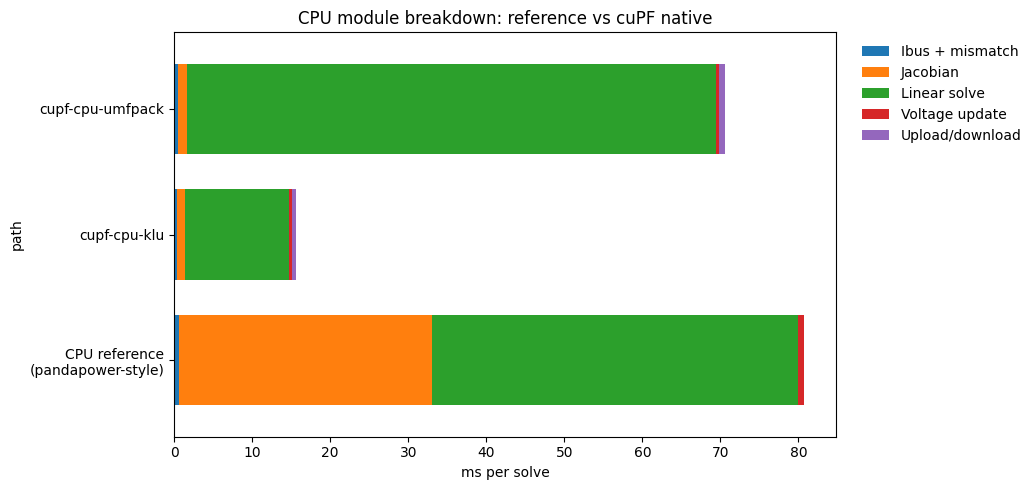

In [10]:
# CPU reference: pandapower-style stage profiler on the same large case.
reference_trace = tu.newton_trace(case, tolerance=1e-8, max_iter=50)
reference_stage = tu.cpu_reference_stage_table(reference_trace)
display(reference_stage.round(3))

variants = [
    'cupf-cpu-umfpack-native',
    'cupf-cpu-klu-native',
]
run_name = tu.timestamp_run_name('tutorial-cpu-native')
display(tu.command_plan_table([
    ('run cuPF CPU native variants', tu.tutorial_benchmark_command(
        variants=variants,
        run_name=run_name,
        cases=[TUTORIAL_CASE],
        repeats=REPEATS,
        warmup=WARMUP,
    )),
]))
if RUN_BENCHMARKS and build.ok:
    run_dir, command = tu.run_tutorial_benchmark(
        variants=variants,
        run_name=run_name,
        cases=[TUTORIAL_CASE],
        repeats=REPEATS,
        warmup=WARMUP,
        timeout=3600,
    )
    print(tu.command_summary(command, tail_lines=20))
else:
    run_dir = tu.tutorial_output_root()
    print('CPU benchmark was not run because the build did not complete or RUN_BENCHMARKS=False.')

summary = tu.benchmark_result_table(run_dir)
summary['variant_key'] = summary['variant'].str.replace('-native', '', regex=False)
display(summary[['variant_key', 'status', 'entrypoint', 'linear_solver', 'jacobian', 'initialize_ms', 'solve_ms', 'worst_residual', 'note']])

timer_names = [
    'NR.iteration.ibus',
    'NR.iteration.mismatch',
    'NR.iteration.mismatch_norm',
    'NR.iteration.jacobian',
    'NR.iteration.factorize',
    'NR.iteration.solve',
    'NR.iteration.voltage_update',
    'NR.solve.upload',
    'NR.solve.download',
]
stages = tu.native_stage_totals(run_dir, timer_names=timer_names)

rows = []
ref_totals = reference_trace.stage_totals_ms
rows.append({
    'path': 'CPU reference\n(pandapower-style)',
    'Ibus + mismatch': float(ref_totals.get('Ibus', 0.0) + ref_totals.get('Mismatch', 0.0) + ref_totals.get('Mismatch norm', 0.0)),
    'Jacobian': float(ref_totals.get('Jacobian', 0.0)),
    'Linear solve': float(ref_totals.get('Linear solve', 0.0)),
    'Voltage update': float(ref_totals.get('Voltage update', 0.0)),
    'Upload/download': 0.0,
})

if not stages.empty:
    runs = tu.load_tutorial_runs(run_dir)
    runs = runs[runs.get('success', 0).astype(str).str.lower().isin(['1', 'true', 'yes'])]
    repeat_counts = runs.groupby('variant').size().to_dict() if not runs.empty else {}
    pivot = stages.pivot_table(index='variant', columns='timer_name', values='total_ms', aggfunc='sum', fill_value=0.0)
    for variant, values in pivot.iterrows():
        denom = max(1, int(repeat_counts.get(variant, REPEATS)))
        label = str(variant).replace('-native', '')
        rows.append({
            'path': label,
            'Ibus + mismatch': (values.get('NR.iteration.ibus', 0.0) + values.get('NR.iteration.mismatch', 0.0) + values.get('NR.iteration.mismatch_norm', 0.0)) / denom,
            'Jacobian': values.get('NR.iteration.jacobian', 0.0) / denom,
            'Linear solve': (values.get('NR.iteration.factorize', 0.0) + values.get('NR.iteration.solve', 0.0)) / denom,
            'Voltage update': values.get('NR.iteration.voltage_update', 0.0) / denom,
            'Upload/download': (values.get('NR.solve.upload', 0.0) + values.get('NR.solve.download', 0.0)) / denom,
        })

stage_compare = pd.DataFrame(rows).set_index('path')
display(stage_compare.round(3))

fig, ax = plt.subplots(figsize=(10.5, 5.0))
plot_cols = ['Ibus + mismatch', 'Jacobian', 'Linear solve', 'Voltage update', 'Upload/download']
stage_compare[plot_cols].plot(kind='barh', stacked=True, ax=ax, width=0.72)
ax.set_xlabel('ms per solve')
ax.set_title('CPU module breakdown: reference vs cuPF native')
ax.legend(frameon=False, bbox_to_anchor=(1.02, 1.0), loc='upper left')
plt.tight_layout()

**정리**

- CPU reference의 `Jacobian`은 sparse derivative 계산과 reduced block assembly 비용이다.
- cuPF native의 `Jacobian`은 fixed pattern 위에서 value slot을 채우는 비용이다.
- `Linear solve`는 reference에서는 `spsolve` 전체이고, cuPF에서는 `factorize + solve`를 합친 값이다.
- `cupf-cpu-umfpack`과 `cupf-cpu-klu`는 같은 cuPF Jacobian fill을 사용하므로, 두 막대의 차이는 sparse linear solver backend 영향으로 읽는다.
- cuPF의 `Linear solve`가 여전히 크면 다음 CPU 최적화는 Jacobian fill보다 sparse factorization/solve backend 쪽이다.
- 05의 GPU 노트북도 같은 관점으로 읽으면, CPU/GPU 모두 Newton pipeline의 어느 module이 지배적인지 직접 비교할 수 있다.